In [ ]:
%matplotlib inline

In [ ]:
import keras
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7,7) # Make the figures a bit bigger
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Conv2D, MaxPooling2D, Flatten
from keras import backend as K

In [ ]:
# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# input image dimensions
_, img_rows, img_cols = x_train.shape

x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1) # Reshape (60000, 28, 28) -> (60000, 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)


# from uint8 (0-255) to float32 to [0,1]
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
n_classes = 10
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, n_classes)   # y_train = [array of numbers from 1 to 10]  ->   array of 10d vectors with 1 on the place of the digit, and 0 on the other ones
y_test = keras.utils.to_categorical(y_test, n_classes)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


**АРХИТЕКТУРА**

In [ ]:
model = Sequential()                                          # последовательно добавляем слои
model.add(Conv2D(64, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape, padding='same'))    # 1ый сверточный слой, 64 фильтра 3*3, activation ReLU, input (28,28,1), padding='same' - adds 0's to the corners
model.add(Dropout(0.2))                                       # отключение 20% нейронов во время обучения
model.add(MaxPooling2D(pool_size=(2, 2)))                     # Pooling - max from (2,2) (28,28,64) -> (14,14,64)
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Dropout(0.2))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Dropout(0.2))
model.add(Flatten())                                          # (4,4,64) -> 64*4*4 vector
model.add(Dense(128, activation='relu'))                      #128 neurons
model.add(Dropout(0.2))
model.add(Dense(n_classes, activation='softmax'))             # 10 outputs for each number/softmax -> probability

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**КОМПИЛЯЦИЯ**

In [ ]:
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(learning_rate=1.0), metrics=['accuracy'])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,986 (808.54 KB)

 Trainable params: 206,986 (808.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history=model.fit(x_train, y_train,
          batch_size=128,
          epochs=10,
          verbose=1,
          validation_data=(x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 294ms/step - accuracy: 0.8246 - loss: 0.5338 - val_accuracy: 0.9822 - val_loss: 0.0614
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 283ms/step - accuracy: 0.9781 - loss: 0.0723 - val_accuracy: 0.9867 - val_loss: 0.0499
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 283ms/step - accuracy: 0.9850 - loss: 0.0469 - val_accuracy: 0.9899 - val_loss: 0.0364
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 284ms/step - accuracy: 0.9873 - loss: 0.0376 - val_accuracy: 0.9932 - val_loss: 0.0243
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 283ms/step - accuracy: 0.9907 - loss: 0.0304 - val_accuracy: 0.9926 - val_loss: 0.0258
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 290ms/step - accuracy: 0.9920 - loss: 0.0259 - val_accuracy: 0.9864 - val_loss: 0.0446
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 286ms/step - accuracy: 0.9913 - loss: 0.0257 - val_accuracy: 0.9929 - val_loss: 0.0215
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 135s 287ms/step - accuracy: 0.9930 -

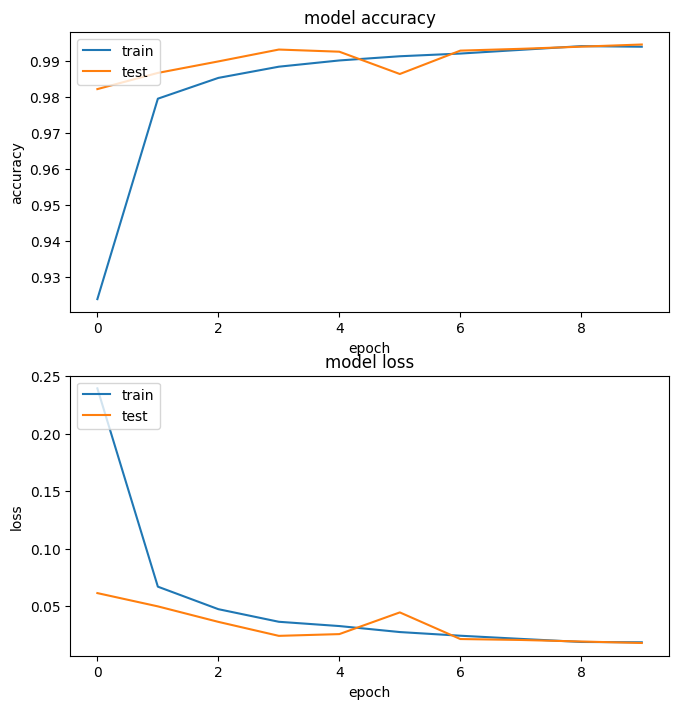

In [ ]:
plt.figure()
plt.subplot(2,1,1)
plt.tight_layout()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

plt.subplot(2,1,2)
plt.tight_layout()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

plt.show()

In [ ]:
# model accuracy on theoriginal test data
score = model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy на исходных данных: {score[1]:.4f}')

Test accuracy на исходных данных: 0.9946


**ФУНКЦИЯ СДВИГАЮЩАЯ ИЗОБРАЖЕНИЕ**

In [ ]:
def shift_image(image, dx, dy):
    '''
    Сдвигает изображение на dx пикселей вправо и dy пикселей вниз.
    Пустые области заполняются нулями (черным).
    '''
    if len(image.shape) == 3:        # (28,28,1) -> (28,28)
        image = image.squeeze()

    h, w = image.shape
    shifted = np.zeros_like(image)

    # shifted image
    x_start = max(0, dx)
    x_end = min(w, w + dx)
    y_start = max(0, dy)
    y_end = min(h, h + dy)

    # original image
    or_x_start = max(0, -dx)
    or_x_end = min(w, w - dx)
    or_y_start = max(0, -dy)
    or_y_end = min(h, h - dy)


    shifted[y_start:y_end, x_start:x_end] = image[or_y_start:or_y_end, or_x_start:or_x_end]

    return shifted.reshape(28, 28, 1)

**СЛУЧАЙНЫЙ СДВИГ В ДИАПАЗОНЕ**

In [ ]:
test_accuracies = {}
max_shift = 10

for shift in range(0, max_shift + 1):
    x_test_shifted = np.zeros_like(x_test)  # empty, the same size as x_test

    for i in range(len(x_test)):
        dx = np.random.randint(-shift, shift + 1)  # random shift in [-shift, shift +1] 'cause  np.random.randint(a, b) gets a =< N < b
        dy = np.random.randint(-shift, shift + 1)
        x_test_shifted[i] = shift_image(x_test[i], dx, dy)

    score = model.evaluate(x_test_shifted, y_test, verbose=0)
    test_accuracies[shift] = score[1]
    print(f'Случайный сдвиг до {shift} пикселей: accuracy = {score[1]:.4f}')

Случайный сдвиг до 0 пикселей: accuracy = 0.9946
Случайный сдвиг до 1 пикселей: accuracy = 0.9890
Случайный сдвиг до 2 пикселей: accuracy = 0.9561
Случайный сдвиг до 3 пикселей: accuracy = 0.8599
Случайный сдвиг до 4 пикселей: accuracy = 0.7187
Случайный сдвиг до 5 пикселей: accuracy = 0.5768
Случайный сдвиг до 6 пикселей: accuracy = 0.4642
Случайный сдвиг до 7 пикселей: accuracy = 0.3687
Случайный сдвиг до 8 пикселей: accuracy = 0.3110
Случайный сдвиг до 9 пикселей: accuracy = 0.2653
Случайный сдвиг до 10 пикселей: accuracy = 0.2307


**СДВИГИ ТОЛЬКО ВПРАВО НА ФИКСИРОВАННУЮ ВЕЛИЧИНУ**

In [ ]:
right_shifts_acc = {}
print("\nCдвиги вправо:")
for dx in range(0, 15):
    x_test_shifted_right = np.zeros_like(x_test)
    for i in range(len(x_test)):
        x_test_shifted_right[i] = shift_image(x_test[i], dx, 0)

    score = model.evaluate(x_test_shifted_right, y_test, verbose=0)
    right_shifts_acc[dx] = score[1]
    print(f'Сдвиг вправо на {dx} пикселей: accuracy = {score[1]:.4f}')


Cдвиги вправо:
Сдвиг вправо на 0 пикселей: accuracy = 0.9946
Сдвиг вправо на 1 пикселей: accuracy = 0.9914
Сдвиг вправо на 2 пикселей: accuracy = 0.9787
Сдвиг вправо на 3 пикселей: accuracy = 0.9158
Сдвиг вправо на 4 пикселей: accuracy = 0.7244
Сдвиг вправо на 5 пикселей: accuracy = 0.5144
Сдвиг вправо на 6 пикселей: accuracy = 0.3505
Сдвиг вправо на 7 пикселей: accuracy = 0.2171
Сдвиг вправо на 8 пикселей: accuracy = 0.1417
Сдвиг вправо на 9 пикселей: accuracy = 0.1065
Сдвиг вправо на 10 пикселей: accuracy = 0.0901
Сдвиг вправо на 11 пикселей: accuracy = 0.0891
Сдвиг вправо на 12 пикселей: accuracy = 0.0779
Сдвиг вправо на 13 пикселей: accuracy = 0.0670
Сдвиг вправо на 14 пикселей: accuracy = 0.0612
